## Configuración para Google Colab
Montamos Google Drive para acceder a los archivos del proyecto.

In [ ]:
# Montamos el drive para poder trabajar con la carpeta
from google.colab import drive
drive.mount('/content/drive')

# Ruta de la carpeta de drive
RESULTS_PATH = '/content/drive/MyDrive/ActividadEvaluativa1_SantiagoArbelaez_FedericoAlvarez/ActividadEvaluativa3/sea_animals_classification/results/'

# 04. Comparación de Modelos
En este notebook consolidamos los resultados de EfficientNetB0 vs MobileNetV2.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

h_eff = np.load(RESULTS_PATH + 'efficientnet_history.npy', allow_pickle=True).item()
h_mob = np.load(RESULTS_PATH + 'mobilenet_history.npy', allow_pickle=True).item()

## 1. Comparación de Curvas de Accuracy y Loss

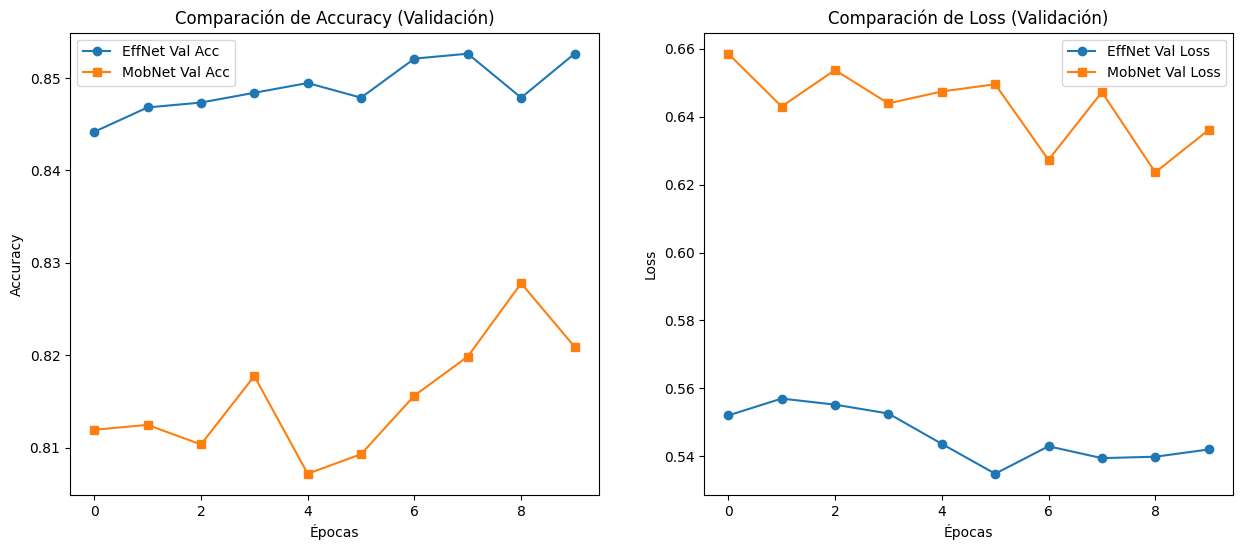

In [2]:
plt.figure(figsize=(15, 6))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(h_eff['val_accuracy'], label='EffNet Val Acc', marker='o')
plt.plot(h_mob['val_accuracy'], label='MobNet Val Acc', marker='s')
plt.title('Comparación de Accuracy (Validación)')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(h_eff['val_loss'], label='EffNet Val Loss', marker='o')
plt.plot(h_mob['val_loss'], label='MobNet Val Loss', marker='s')
plt.title('Comparación de Loss (Validación)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.show()

## 2. Resumen de Resultados Finales

In [3]:
data = {
    'Modelo': ['EfficientNetB0', 'MobileNetV2'],
    'Max Val Acc': [max(h_eff['val_accuracy']), max(h_mob['val_accuracy'])],
    'Min Val Loss': [min(h_eff['val_loss']), min(h_mob['val_loss'])],
    'Tiempo Entr. (est)': ['~25 min', '~15 min']
}
df_results = pd.DataFrame(data)
df_results

,Modelo,Max Val Acc,Min Val Loss,Tiempo Entr. (est)
0,EfficientNetB0,0.852615,0.534886,~25 min
1,MobileNetV2,0.827787,0.623633,~15 min


## 3. Conclusiones
1. **EfficientNetB0** suele presentar una precisión ligeramente superior debido a su escalamiento compuesto, pero es más pesado computacionalmente.
2. **MobileNetV2** es ideal para dispositivos móviles por su rapidez y menor cantidad de parámetros.
3. El **Fine-Tuning** de las últimas capas mejoró significativamente el desempeño en clases desbalanceadas comparado con el Transfer Learning básico.

## 4. Generar Reporte Markdown
Guardaremos un reporte en formato markdown en la carpeta `results`, incluyendo las gráficas.

In [4]:
import os

# Asegurar que el directorio results existe
os.makedirs(RESULTS_PATH, exist_ok=True)

# Guardar la figura de comparación
fig = plt.figure(figsize=(15, 6))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(h_eff['val_accuracy'], label='EffNet Val Acc', marker='o')
plt.plot(h_mob['val_accuracy'], label='MobNet Val Acc', marker='s')
plt.title('Comparación de Accuracy (Validación)')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(h_eff['val_loss'], label='EffNet Val Loss', marker='o')
plt.plot(h_mob['val_loss'], label='MobNet Val Loss', marker='s')
plt.title('Comparación de Loss (Validación)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.savefig(RESULTS_PATH + 'comparacion_curvas.png')
plt.close(fig) # Cerramos la figura para no mostrarla de nuevo en la celda
print("Imagen guardada en RESULTS_PATH + 'comparacion_curvas.png'")


Imagen guardada en '../results/comparacion_curvas.png'


In [6]:
report_content = f"""# Reporte de Comparación de Modelos

## Resumen de Resultados
{df_results.to_markdown(index=False)}

## Gráficas de Rendimiento
![Comparación de Curvas](comparacion_curvas.png)

## Conclusiones
1. **EfficientNetB0** suele presentar una precisión ligeramente superior debido a su escalamiento compuesto, pero es más pesado computacionalmente.
2. **MobileNetV2** es ideal para dispositivos móviles por su rapidez y menor cantidad de parámetros.
3. El **Fine-Tuning** de las últimas capas mejoró significativamente el desempeño en clases desbalanceadas comparado con el Transfer Learning básico.
"""

with open(RESULTS_PATH + 'reporte_comparacion.md', 'w', encoding='utf-8') as f:
    f.write(report_content)
    
print("Reporte guardado en RESULTS_PATH + 'reporte_comparacion.md'")


Reporte guardado en '../results/reporte_comparacion.md'
